# Introduction to the Digital Twin Part 4: Predictors and WindFields

In the first three notebooks, we have created some simulated scenarios and used the `evolve` method to step through them, but we haven't looked in any detail at what happens when we call `evolve`.

Essentially, the task of telling the simulation where an aircraft will move to in a time step, is done by a *Predictor*.  The design of bluebird_dt is such that we have a common interface for Predictors, so users can choose between a selection of implemented classes, or, experienced developers can create their own.

Let's instantiate a simulated scenario, and take a look at the Predictor.

In [1]:
from bluebird_dt.simulator import Simulator
sim = Simulator.from_category("Springfield", "example-scenario")

In [2]:
sim.manager.predictor

We can see that we're using a "SimplePredictor".   We can look at the code for this in `bluebird_dt/predictor/simple_predictor.py` or on the auto-generated code docs in the web documentation.

In [3]:
help(sim.manager.predictor)

Help on SimplePredictor in module bluebird_dt.predictor.simple_predictor object:

class SimplePredictor(bluebird_dt.predictor.predictor.Predictor)
 |  SimplePredictor(dt: 'float', fix_proximity_threshold: 'float', fixes: 'Fixes | None' = None)
 |  
 |  Evolves Aircraft with constant speed and vertical speed along their heading.
 |  
 |  Method resolution order:
 |      SimplePredictor
 |      bluebird_dt.predictor.predictor.Predictor
 |      abc.ABC
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, dt: 'float', fix_proximity_threshold: 'float', fixes: 'Fixes | None' = None)
 |      Construct a new instance.
 |      
 |      Parameters
 |      ----------
 |      dt: float
 |          The internal step time of the predictor. The time taken between each control point within the returned
 |          Trajectory is dt.
 |      fix_proximity_threshold: float
 |          When an Aircraft is <= fix_proximity_threshold distance from the next Fix on its Route, the Fix

One important thing to note with the SimplePredictor is that it doesn't have an intrinsic way to determine `tas`, the *true air speed* of an aircraft.  Instead, it uses `cas`, the *cleared air speed*.

Other predictors are being developed that can use look-up tables for different aircraft types to give a better estimate for the true air speed.


### Rolling out a trajectory using a predictor

If you are creating an agent, it might be useful to use a Predictor to look at hypothetical trajectories for aircraft (e.g. to see if they will conflict with other aircraft in the future).  For this, we can use the `predict_trajectory` method that is supplied by all Predictors.

In [4]:
from copy import deepcopy
from bluebird_dt.predictor import SimplePredictor
sim = Simulator.from_category("Artificial", "I-Sector Two Aircraft")
pred = SimplePredictor(dt=1, fix_proximity_threshold=0.5, fixes=sim.manager.environment.airspace.fixes)
# make a copy of one of the aircraft in the simulation, so we can see how it might evolve if we give it a target heading and FL
candidate_aircraft = deepcopy(sim.manager.environment.aircraft["AIR0"])
candidate_aircraft.on_route = False

In [5]:
# look at trajectory over the next 60 seconds if we don't change anything
traj = pred.predict_trajectory(candidate_aircraft, 60)

In [6]:
# plotting the trajectory
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import SVG, Image

%matplotlib inline

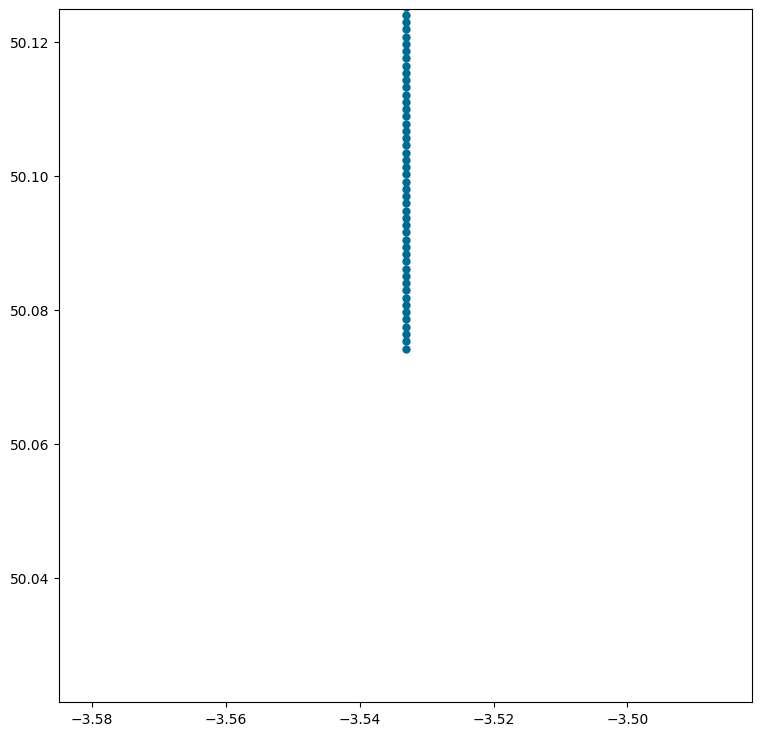

In [7]:
from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D(candidate_aircraft.lat, candidate_aircraft.lon)
view_width = 4 
aspect_ratio = 1

radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_trajectory(traj)

In [8]:
# see what happens if we change the aircraft heading to 270 and flight level to 360
candidate_aircraft.heading_changing_to = 270
candidate_aircraft.selected_instructions.fl = 360
traj = pred.predict_trajectory(candidate_aircraft, 60)

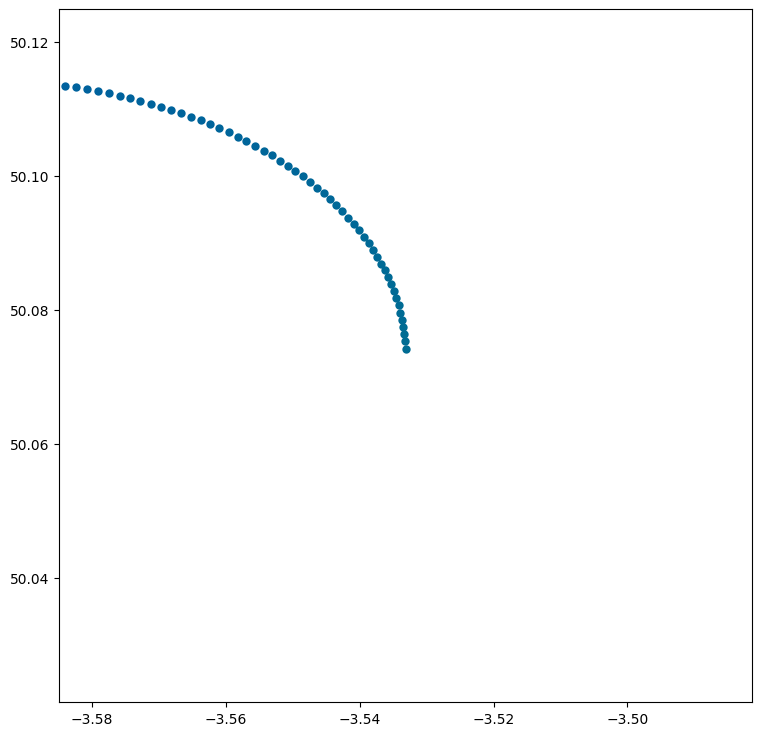

In [9]:
radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_trajectory(traj)

So we can see that the aircraft makes a turn, but it is not instantaneous - there is a relatively small heading change per second in the predictor's model of the aircraft behaviour.

### Using a different Predictor

We can specify a predictor when we create the Simulator instance by calling `from_category`.   As an example, let's use the RouteFollowPredictor:

In [10]:
from bluebird_dt.predictor import RouteFollowPredictor
pred = RouteFollowPredictor(dt=1, fix_proximity_threshold = 0.5, fixes=None)
sim = Simulator.from_category("Springfield", "example-scenario", predictor = pred)

In [11]:
type(sim.manager.predictor)

bluebird_dt.predictor.route_follow_predictor.RouteFollowPredictor

### Making our own Predictor

It is not recommended, unless you really know what you are doing, but the modular BluebirdATC code makes it possible for people to implement their own predictors, as long as they inherit from the `Predictor` base class in `bluebird-dt/predictors/predictor.py`.  
The only method that is mandatory to override is `predict`, which looks like:
```
@abstractmethod
    def _predict(
        self,
        aircraft: Aircraft,
        time_evolve: float,
        environment_time: float = 0.0,
        wind_field: WindField | None = None,
    ) -> tuple[list[Pos4D], Aircraft]:
```

In [13]:
from typing_extensions import override
from bluebird_dt.core import Aircraft, Pos4D, WindField
from bluebird_dt.predictor import Predictor

class StayStillPredictor(Predictor):
    """
    A dummy example of a predictor, that makes all aircraft stay where they are.
    """
    @override
    def _predict(self, aircraft: Aircraft, time_evolve: float, environment_time: float = 0.0, wind_field: WindField | None = None):
        num_steps is time_evolve // self.dt
        control_points = []
        for i in range(num_steps):
            cp = Pos4D(lat=aircraft.lat, lon=aircraft.lon, fl=aircraft.fl, time=environment_time+i*self.dt)
            control_points.append(cp)
        return control_points, aircraft
            
            

In [14]:
pred = StayStillPredictor(dt=1.0, fix_proximity_threshold=0.5, fixes=None)
sim = Simulator.from_category("Springfield", "example-scenario", predictor=pred)
print(type(sim.manager.predictor))

<class '__main__.StayStillPredictor'>


## Wind fields

The predictors are responsible for updating the positions of aircraft between time steps.  In order to do this, they may take account of the *wind* in the area.   In bluebird_dt, wind can be represented by a WindVector, giving the strength and direction of the wind, and a WindField, which is a collection of WindVectors at different points in space.

We can create a simple uniform wind field, with a wind speed of 20m/s, blowing from the East:

In [15]:
from bluebird_dt.core import WindField
wf = WindField.uniform(wind_speed=20, wind_direction=90)

We can visualise the effect of this wind field on a simple Two Aircraft scenario.   When we first create the scenario, both aircraft will be "on_route", meaning they will fly directly over the fixes on their specified route.   We can set one of the aircraft ("AIR0") to no longer be on route, to see the effect of the wind.

In [16]:
# Start up scenario with the default "SimplePredictor" predictor.
sim = Simulator.from_category("Artificial", "I-Sector Two Aircraft")
# set on_route to False for one aircraft
sim.manager.environment.aircraft["AIR0"].on_route = False
# set the wind field
sim.manager.environment.wind_field = wf

In [17]:
import matplotlib.pyplot as plt

%matplotlib inline

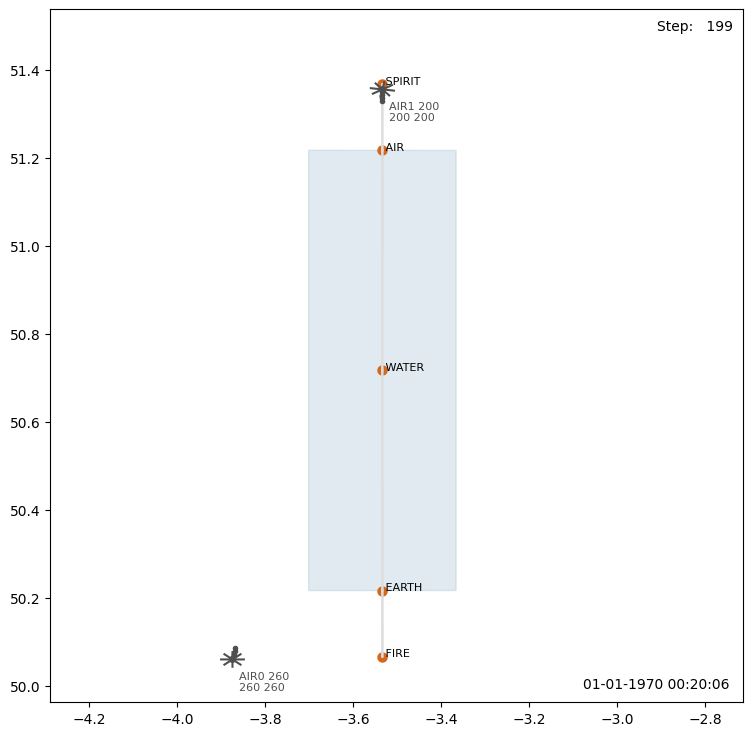

In [18]:
import IPython.display

from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D.from_str("50.75N 3.5W")
view_width = 60.0  # [nmi] about 1 degree of longitude
aspect_ratio = 1

radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(200):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

We can see that while "AIR1" continues to follow it's route, "AIR0" is being blown to the west by the wind.

## Conclusions

In this notebook we have looked at Predictors, which contain the code used by the simulation to update aircraft positions. Key points are:
* The modular design of `bluebird-dt` means that users can choose which Predictor to use in their scenario, and even create their own (though this is recommended for experts only).
* Predictors are used "under the hood" to update aircraft positions when we call `Simulator.evolve`, but they can also be used (e.g. by Agents) to roll out hypothetical trajectories.
* One of the inputs that Predictors can use in their calculations of aircraft position, is a **WindField**, defined as a set of **WindVector**s at different points in space.
* Depending on how it is implemented in the Predictor, wind may blow an aircraft away from it's nominal heading, but if the aircraft's `on_route` attribute is set, it should continue to follow the route.